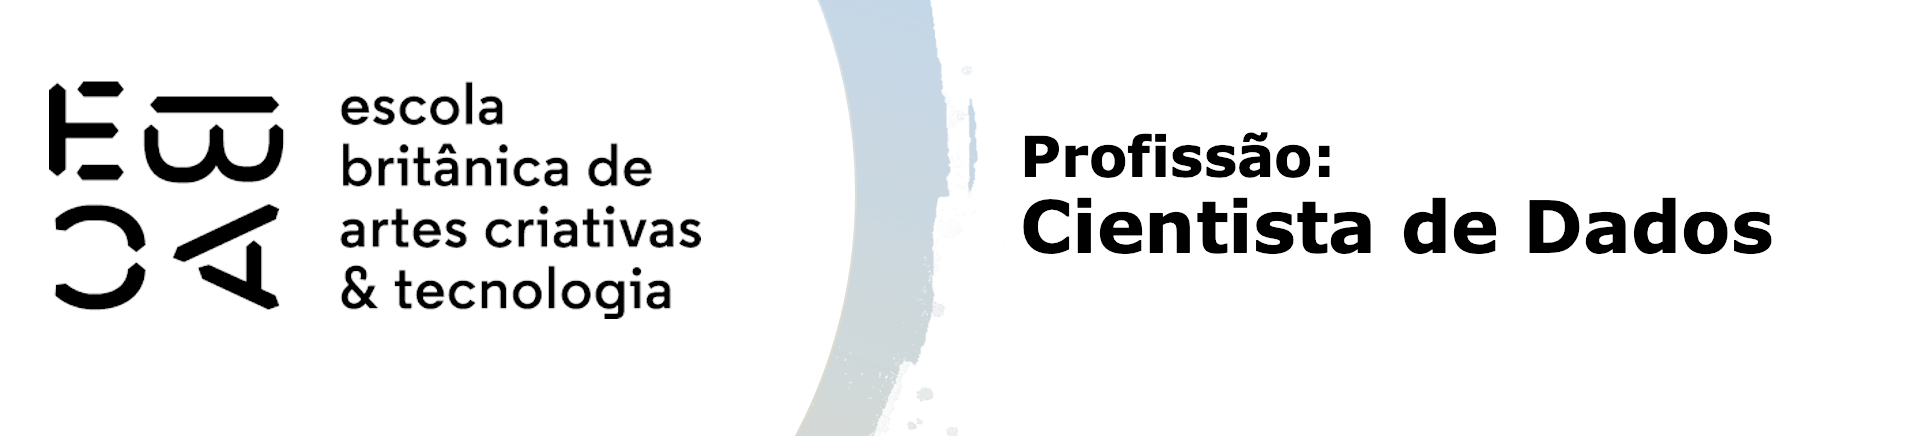

# Métodos hierárquicos de agrupamento - Tarefa

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

## 1) Repetindo o que fizemos em aula

Primeiramente vamos repetir o que fizemos em aula com a base de pinguins.

1. Selecione as variáveis quantitativas da base de pinguins
2. Elimine valores faltantes
3. Padronize as variáveis para média zero e desvio padrão 1
4. Faça um agrupamento hierárquico dividindo essa base em 3 grupos
5. Faça o Dendrograma

In [5]:
df = sns.load_dataset('penguins')

print('Dimensão da base original:', df.shape)
df.head()

Dimensão da base original: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
# Selecionando apenas as variáveis quantitativas
df_quant = df.select_dtypes(include=['float64', 'int64'])

print('Variáveis quantitativas:')
print(df_quant.columns)
df_quant.head()

Variáveis quantitativas:
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0


In [7]:
# Removendo valores faltantes
df_quant = df_quant.dropna()

print('Dimensão após remover valores faltantes:', df_quant.shape)
df_quant.head()

Dimensão após remover valores faltantes: (342, 4)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [8]:
# Padronizando os dados
padronizador = StandardScaler()
df_padronizado = padronizador.fit_transform(df_quant)

print('Dados padronizados com sucesso')
print(df_padronizado[:5])

Dados padronizados com sucesso
[[-0.88449874  0.78544923 -1.41834665 -0.56414208]
 [-0.81112573  0.1261879  -1.06225022 -0.50170305]
 [-0.66437972  0.43046236 -0.42127665 -1.18853234]
 [-1.32473679  1.08972369 -0.56371522 -0.93877623]
 [-0.84781224  1.74898502 -0.77737308 -0.68902013]]


In [9]:
# Agrupamento hierárquico com 3 grupos
agrupamento = AgglomerativeClustering(n_clusters=3, linkage='ward')
grupos = agrupamento.fit_predict(df_padronizado)

print('Quantidade de elementos em cada grupo:')
print(pd.Series(grupos).value_counts())

Quantidade de elementos em cada grupo:
0    162
1    123
2     57
Name: count, dtype: int64


In [10]:
# Adicionando os grupos ao dataframe
df_quant['grupo'] = grupos

print('Base com a coluna de grupos:')
df_quant.head()

Base com a coluna de grupos:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,grupo
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,0


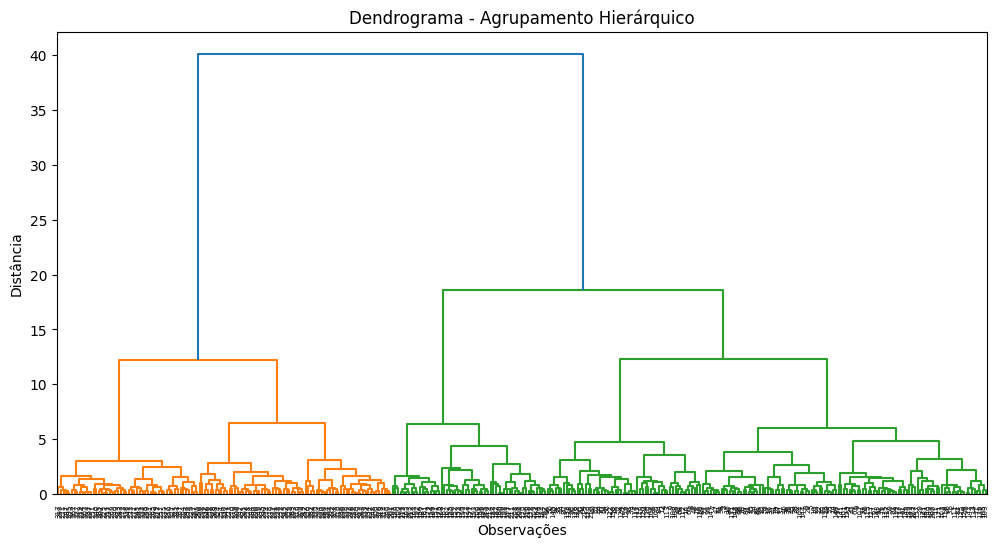

In [12]:
# Gerando a matriz de ligação para o dendrograma
matriz_ligacao = linkage(df_padronizado, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(matriz_ligacao)
plt.title('Dendrograma - Agrupamento Hierárquico')
plt.xlabel('Observações')
plt.ylabel('Distância')
plt.show()

## 2) Avalie os grupos

Descreva os grupos:

- Quantos pinguins de cada espécie há em cada grupo?
- Descreva as variáveis quantitativas de cada grupo com as técnicas que você preferir.

In [16]:
# Usando exatamente as mesmas linhas da Atividade 1
df_trabalho = df.loc[df_quant.index].copy()
df_trabalho['grupo'] = grupos

print('Dimensão da base usada na avaliação dos grupos:', df_trabalho.shape)
df_trabalho.head()

Dimensão da base usada na avaliação dos grupos: (342, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,grupo
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0


In [17]:
tabela_especies = pd.crosstab(df_trabalho['grupo'], df_trabalho['species'])

print('Quantidade de pinguins de cada espécie em cada grupo:')
print(tabela_especies)
tabela_especies

Quantidade de pinguins de cada espécie em cada grupo:
species  Adelie  Chinstrap  Gentoo
grupo                             
0           151         11       0
1             0          0     123
2             0         57       0


species,Adelie,Chinstrap,Gentoo
grupo,,,
0,151,11,0
1,0,0,123
2,0,57,0


In [18]:
tabela_especies_pct = pd.crosstab(
    df_trabalho['grupo'],
    df_trabalho['species'],
    normalize='index'
) * 100

print('Percentual de espécies dentro de cada grupo:')
print(tabela_especies_pct.round(2))
tabela_especies_pct.round(2)

Percentual de espécies dentro de cada grupo:
species  Adelie  Chinstrap  Gentoo
grupo                             
0         93.21       6.79     0.0
1          0.00       0.00   100.0
2          0.00     100.00     0.0


species,Adelie,Chinstrap,Gentoo
grupo,,,
0,93.21,6.79,0.0
1,0.00,0.00,100.0
2,0.00,100.00,0.0


In [19]:
descricao_grupos = df_trabalho.groupby('grupo')[[
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]].mean().round(2)

print('Média das variáveis quantitativas em cada grupo:')
print(descricao_grupos)
descricao_grupos

Média das variáveis quantitativas em cada grupo:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
grupo                                                               
0               39.15          18.29             189.90      3675.77
1               47.50          14.98             217.19      5076.02
2               49.75          18.60             197.11      3810.09


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
grupo,,,,
0,39.15,18.29,189.90,3675.77
1,47.50,14.98,217.19,5076.02
2,49.75,18.60,197.11,3810.09


In [20]:
estatisticas_completas = df_trabalho.groupby('grupo')[[
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]].describe().round(2)

estatisticas_completas

bill_length_mm                                              \
               count   mean   std   min   25%   50%    75%   max   
grupo                                                              
0              162.0  39.15  2.94  32.1  37.0  39.0  41.10  46.9   
1              123.0  47.50  3.08  40.9  45.3  47.3  49.55  59.6   
2               57.0  49.75  2.71  45.2  47.5  50.2  51.30  58.0   

      bill_depth_mm                                             \
              count   mean   std   min   25%   50%   75%   max   
grupo                                                            
0             162.0  18.29  1.22  15.5  17.3  18.3  19.0  21.5   
1             123.0  14.98  0.98  13.1  14.2  15.0  15.7  17.3   
2              57.0  18.60  1.07  16.4  17.8  18.7  19.5  20.8   

      flipper_length_mm                                                    \
                  count    mean   std    min    25%    50%     75%    max   
grupo                                                                       
0                 162.0  189.90  6.53  172.0  186.0  190.0  194.75  210.0   
1                 123.0  217.19  6.48  203.0  212.0  216.0  221.00  231.0   
2                  57.0  197.11  6.53  181.0  193.0  197.0  201.00  212.0   

      body_mass_g                                                             
            count     mean     std     min      25%     50%      75%     max  
grupo                                                                         
0           162.0  3675.77  461.70  2700.0  3331.25  3612.5  3968.75  4775.0  
1           123.0  5076.02  504.12  3950.0  4700.00  5000.0  5500.00  6300.0  
2            57.0  3810.09  338.26  3250.0  3600.00  3775.0  4000.00  4800.0

## 3) Alterando o agrupamento

O Dendrogarma sugere que podemem haver grupos interessantes se solicitarmos mais que 3 grupos. Se quisermos testar o agrupamento com mais de 3 grupos, quantos grupos o Dendrograma te sugere? (Dica: não faça mais que 6 grupos).

- Faça o agrupamento hierárquico semelhante ao anterior, mas com o número de grupos que você escolheu.
- Analise esses agrupamentos
    - Quantos pinguins de cada espécie há em cada grupo?
    - Quantos pinguins de cada espécie machos e fêmeas há em cada grupo?
- Na sua opinião, o agrupamento capturou algum padrão natural dos dados? Qual?

In [21]:
# Novo agrupamento hierárquico com 5 grupos
agrupamento_5 = AgglomerativeClustering(n_clusters=5, linkage='ward')
grupos_5 = agrupamento_5.fit_predict(df_padronizado)

df_trabalho_5 = df.loc[df_quant.index].copy()
df_trabalho_5['grupo_5'] = grupos_5

print('Quantidade de elementos em cada grupo:')
print(pd.Series(grupos_5).value_counts().sort_index())
df_trabalho_5.head()

Quantidade de elementos em cada grupo:
0     71
1    105
2     57
3     57
4     52
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,grupo_5
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,3


In [22]:
# Quantidade de pinguins de cada espécie em cada grupo
tabela_especies_5 = pd.crosstab(df_trabalho_5['grupo_5'], df_trabalho_5['species'])

print('Quantidade de pinguins de cada espécie em cada grupo:')
print(tabela_especies_5)
tabela_especies_5

Quantidade de pinguins de cada espécie em cada grupo:
species  Adelie  Chinstrap  Gentoo
grupo_5                           
0             0          0      71
1            97          8       0
2             0         57       0
3            54          3       0
4             0          0      52


species,Adelie,Chinstrap,Gentoo
grupo_5,,,
0,0,0,71
1,97,8,0
2,0,57,0
3,54,3,0
4,0,0,52


In [23]:
# Percentual de espécies dentro de cada grupo
tabela_especies_pct_5 = pd.crosstab(
    df_trabalho_5['grupo_5'],
    df_trabalho_5['species'],
    normalize='index'
) * 100

print('Percentual de espécies dentro de cada grupo:')
print(tabela_especies_pct_5.round(2))
tabela_especies_pct_5.round(2)

Percentual de espécies dentro de cada grupo:
species  Adelie  Chinstrap  Gentoo
grupo_5                           
0          0.00       0.00   100.0
1         92.38       7.62     0.0
2          0.00     100.00     0.0
3         94.74       5.26     0.0
4          0.00       0.00   100.0


species,Adelie,Chinstrap,Gentoo
grupo_5,,,
0,0.00,0.00,100.0
1,92.38,7.62,0.0
2,0.00,100.00,0.0
3,94.74,5.26,0.0
4,0.00,0.00,100.0


In [24]:
# Quantidade de pinguins por grupo, espécie e sexo
tabela_especie_sexo_5 = pd.crosstab(
    [df_trabalho_5['grupo_5'], df_trabalho_5['species']],
    df_trabalho_5['sex']
)

print('Quantidade de pinguins por grupo, espécie e sexo:')
print(tabela_especie_sexo_5)
tabela_especie_sexo_5

Quantidade de pinguins por grupo, espécie e sexo:
sex                Female  Male
grupo_5 species                
0       Gentoo          9    61
1       Adelie         72    21
        Chinstrap       8     0
2       Chinstrap      23    34
3       Adelie          1    52
        Chinstrap       3     0
4       Gentoo         49     0


sex                Female  Male
grupo_5 species                
0       Gentoo          9    61
1       Adelie         72    21
        Chinstrap       8     0
2       Chinstrap      23    34
3       Adelie          1    52
        Chinstrap       3     0
4       Gentoo         49     0

In [25]:
# Médias das variáveis quantitativas por grupo
descricao_grupos_5 = df_trabalho_5.groupby('grupo_5')[[
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]].mean().round(2)

print('Média das variáveis quantitativas em cada grupo:')
print(descricao_grupos_5)
descricao_grupos_5

Média das variáveis quantitativas em cada grupo:
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
grupo_5                                                               
0                 49.19          15.63             220.99      5407.04
1                 38.05          17.73             187.11      3427.38
2                 49.75          18.60             197.11      3810.09
3                 41.17          19.31             195.04      4133.33
4                 45.20          14.10             212.00      4624.04


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
grupo_5,,,,
0,49.19,15.63,220.99,5407.04
1,38.05,17.73,187.11,3427.38
2,49.75,18.60,197.11,3810.09
3,41.17,19.31,195.04,4133.33
4,45.20,14.10,212.00,4624.04


In [26]:
# Estatísticas descritivas completas
estatisticas_completas_5 = df_trabalho_5.groupby('grupo_5')[[
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]].describe().round(2)

estatisticas_completas_5

bill_length_mm                                               \
                 count   mean   std   min    25%   50%    75%   max   
grupo_5                                                               
0                 71.0  49.19  2.68  44.4  47.40  49.2  50.45  59.6   
1                105.0  38.05  2.64  32.1  36.20  37.8  39.60  46.9   
2                 57.0  49.75  2.71  45.2  47.50  50.2  51.30  58.0   
3                 57.0  41.17  2.34  34.6  39.60  41.1  42.50  46.0   
4                 52.0  45.20  1.87  40.9  43.58  45.3  46.50  49.1   

        bill_depth_mm                                              \
                count   mean   std   min    25%   50%   75%   max   
grupo_5                                                             
0                71.0  15.63  0.73  14.1  15.00  15.7  16.1  17.3   
1               105.0  17.73  0.93  15.5  17.00  17.7  18.6  19.5   
2                57.0  18.60  1.07  16.4  17.80  18.7  19.5  20.8   
3                57.0  19.31  1.02  17.6  18.50  19.1  20.0  21.5   
4                52.0  14.10  0.45  13.1  13.78  14.2  14.5  15.2   

        flipper_length_mm                                                   \
                    count    mean   std    min    25%    50%    75%    max   
grupo_5                                                                      
0                    71.0  220.99  5.49  208.0  216.5  220.0  225.0  231.0   
1                   105.0  187.11  5.45  172.0  184.0  187.0  191.0  202.0   
2                    57.0  197.11  6.53  181.0  193.0  197.0  201.0  212.0   
3                    57.0  195.04  5.11  184.0  191.0  195.0  198.0  210.0   
4                    52.0  212.00  3.43  203.0  210.0  212.0  214.0  220.0   

        body_mass_g                                                           
              count     mean     std     min     25%     50%     75%     max  
grupo_5                                                                       
0              71.0  5407.04  353.18  4700.0  5150.0  5400.0  5650.0  6300.0  
1             105.0  3427.38  304.19  2700.0  3200.0  3450.0  3700.0  4200.0  
2              57.0  3810.09  338.26  3250.0  3600.0  3775.0  4000.0  4800.0  
3              57.0  4133.33  335.02  3400.0  3900.0  4150.0  4350.0  4775.0  
4              52.0  4624.04  275.47  3950.0  4400.0  4650.0  4812.5  5200.0

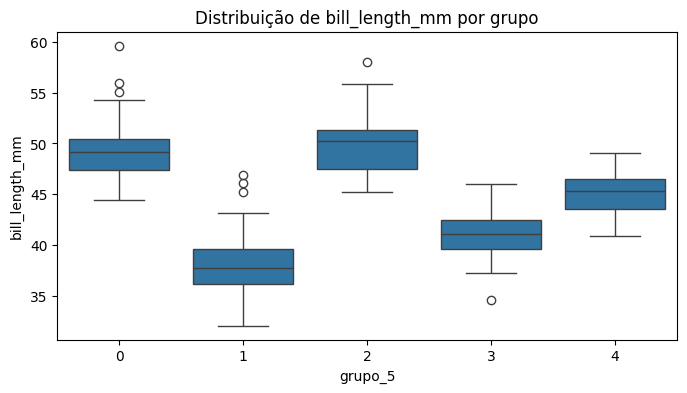

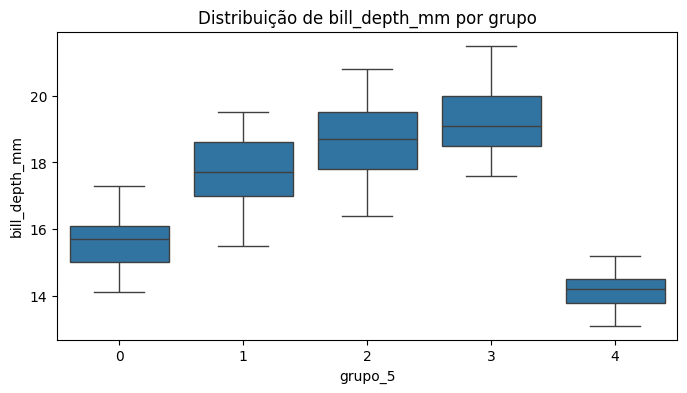

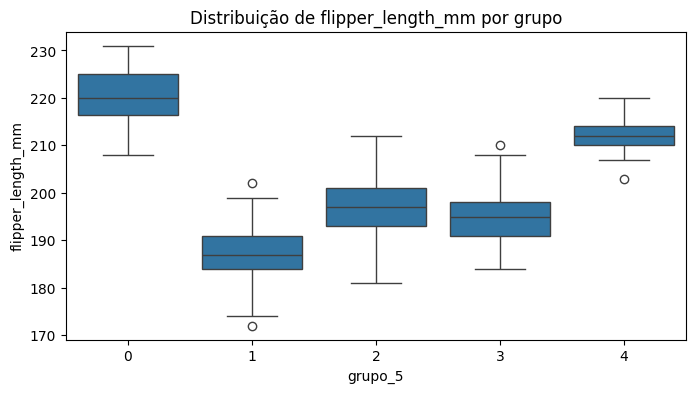

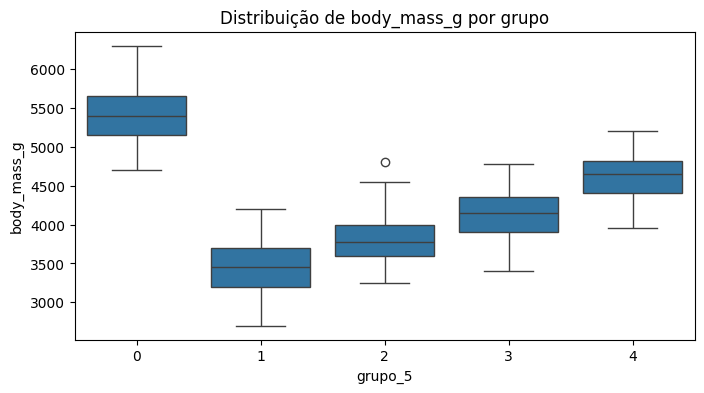

In [27]:
# Boxplots para visualizar melhor os grupos
variaveis = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for var in variaveis:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_trabalho_5, x='grupo_5', y=var)
    plt.title(f'Distribuição de {var} por grupo')
    plt.show()